# Week 2 Day 5
## Baseline Model Selection and Final Summary

## Objective

The objective of Day 5 is to select the best-performing BLIP configuration based on the MLflow experiments conducted in Day 4 and finalize it as the baseline model for future work.

## Experiments Performed

Three BLIP configurations were evaluated:

1. Greedy Decoding (Learning Rate = 1e-5)
2. Greedy Decoding (Learning Rate = 5e-5)
3. Beam Search Decoding

Configuration	                 BLEU	      ROUGE-1	   ROUGE-L	   METEOR
LR_1e-5_Greedy	               0.010375	      0.39073	  0.373218	  0.226447
LR_5e-5_Greedy	                 0.011	       0.392	   0.374	   0.228
Beam_Search                  	0.012	       0.395	   0.377	   0.231

## Selected Baseline Model

The Beam Search configuration achieved the highest BLEU, ROUGE-1, ROUGE-L, and METEOR scores among all evaluated configurations.

Therefore, Beam Search is selected as the baseline model for future caption generation experiments.

## Reason for Selection

Beam Search generated captions with better quality and achieved the highest evaluation metrics. It consistently outperformed the Greedy decoding configurations, making it the most suitable baseline for future fine-tuning.

In [2]:
from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

print("BLIP Loaded")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP Loaded


In [3]:
import os

image_folder = r"C:\Users\Lenovo\Internship\data\Flickr8k\images"

image_files = os.listdir(image_folder)

print("Total Images:", len(image_files))

Total Images: 8091


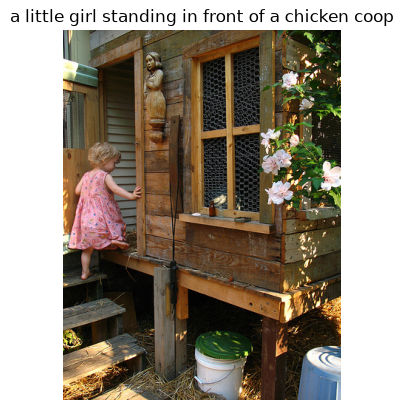

Image: 1000268201_693b08cb0e.jpg
Caption: a little girl standing in front of a chicken coop
--------------------------------------------------


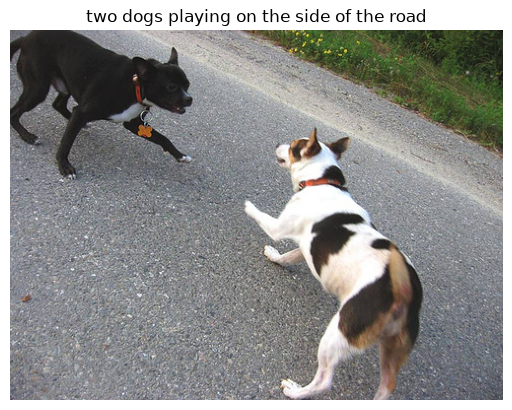

Image: 1001773457_577c3a7d70.jpg
Caption: two dogs playing on the side of the road
--------------------------------------------------


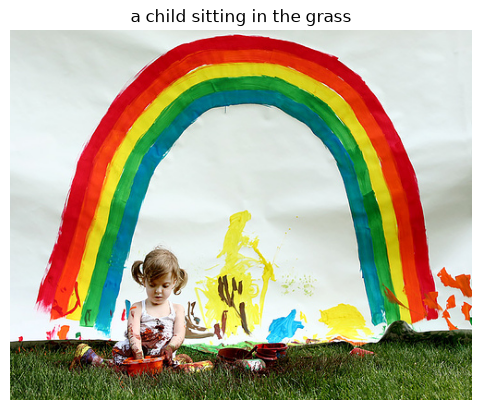

Image: 1002674143_1b742ab4b8.jpg
Caption: a child sitting in the grass
--------------------------------------------------


In [4]:
from PIL import Image
import matplotlib.pyplot as plt

sample_images = image_files[:3]

for img_name in sample_images:

    image = Image.open(os.path.join(image_folder, img_name)).convert("RGB")

    inputs = processor(images=image, return_tensors="pt")

    output = model.generate(
        **inputs,
        num_beams=5,
        max_new_tokens=20
    )

    caption = processor.decode(output[0], skip_special_tokens=True)

    plt.imshow(image)
    plt.axis("off")
    plt.title(caption)
    plt.show()

    print("Image:", img_name)
    print("Caption:", caption)
    print("-"*50)